Computing Lightcurve : 100%|██████████| 100/100 [00:12<00:00,  8.19it/s]


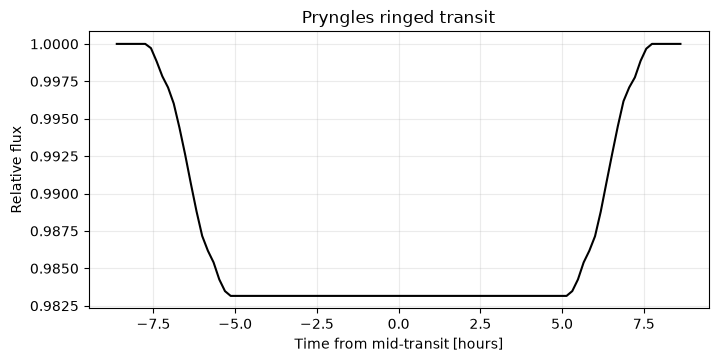

In [ ]:
# PhotoRing Simulator (https://seap-udea.github.io/apps/photoring-simulator) → pyPplusS (Rein & Ofir 2019)
# Generated from the current photoring-simulator configuration.
# Uncomment in Colab if pryngles is not installed yet:
# %pip install "rebound>=4.0,<4.7" pryngles

import numpy as np
import matplotlib.pyplot as plt
import pryngles as pr

import numpy as np
if not hasattr(np, "NaN"):np.NaN = np.nan

# Constants
deg = np.pi / 180 # factor from degrees to radians
rad = 1 / deg

# System parameters
p = 0.084 # planet radius [R*]
fi = 1.58 # inner ring [Rp]
fe = 2.35 # outer ring [Rp]
tilt = 25.0*deg # sky-plane position angle / tilt
ir = 55.0*deg # sky-plane inclination (0=face-on, 90=edge-on)
b  = 0.25 # impact parameter [R*]
alpha = 0.37 # normal ring transmission exp(-tau_normal)
mstar = 1.0 # M* [M_sun]
rstar = 1.0 # R* [R_sun]
mpjup = 0.3 # Mp [Mjup]
porb= 365.25 # Porb [days]
a_rs= 215.0 # a/R*

# Define the system
sys = pr.System(units=["au", "msun", "day"])

# Properties in units of pryngles
tau = -np.log(alpha)
rstar_pr = rstar * pr.Consts.rsun / sys.ul # from Rsun to au
a_pr = a_rs * rstar_pr
rp_pr = p * rstar_pr
iorb = np.arccos(b/a_rs)

# Convert from projection angles to physical (pryngles) angles
i_pr = np.arccos(np.sin(ir) * np.cos(tilt))
roll_pr = np.arctan2(np.sin(ir) * np.sin(tilt), np.cos(ir))

# Create system
nspangles = 300
star = sys.add(
    kind="Star",
    name="Star",
    m=mstar,
    radius=rstar_pr,
    limb_coeffs=[0.0, 0.0],
    nspangles=nspangles,
)

planet = sys.add(
    kind="Planet",
    parent=star,
    name="Planet",
    m=0,
    a=a_pr,
    e=0.0,
    radius=rp_pr,
    nspangles=nspangles,
)

ring = sys.add(
    kind="Ring",
    parent=planet,
    name="Ring",
    fi=fi,
    fe=fe,
    i=i_pr,
    roll=roll_pr,
    tau_gray_optical=tau,
    nspangles=nspangles,
)
sys.initialize_simulation()
sys.spangle_system()

ts = np.linspace(-8.62, 8.62, 100) / 24 # in days
lc = sys.compute_lightcurve(ts, bodies=['Planet', 'Ring'], effects=['transit'], observer=[0,np.pi/2-iorb])

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(ts*24, lc['total_flux'], 'k-', label='Pryngles')
ax.set_xlabel("Time from mid-transit [hours]")
ax.set_ylabel("Relative flux")
ax.set_title(f"Pryngles ringed transit")
ax.grid(True, alpha=0.25)
plt.show()